In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


In [15]:
image = torch.tensor([
    [0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0.],
    [1., 1., 1., 1., 1.],   # horizontal edge here
    [0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0.],
], ).unsqueeze(0).unsqueeze(0)

#horizontal edge detector filter
horiz_filter = torch.tensor([
    [[-1., -1., -1.],
     [ 0.,  0.,  0.],
     [ 1.,  1.,  1.]]
]).unsqueeze(0)

conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    bias=False
)

conv.weight.data = horiz_filter
with torch.no_grad():
  result = conv(image)

print("Original image (5x5):")
print(image.squeeze().numpy())
print("\nAfter horizontal edge filter:")
print(result.squeeze().detach().numpy())
print("""
High values = horizontal edge detected there
Low values  = no edge
The filter found the edge at row 2-3
""")

Original image (5x5):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

After horizontal edge filter:
[[ 3.  3.  3.]
 [ 0.  0.  0.]
 [-3. -3. -3.]]

High values = horizontal edge detected there
Low values  = no edge
The filter found the edge at row 2-3



In [16]:
vert_filter = torch.tensor([
    [[-1., 0., 1.],
     [-1., 0., 1.],
     [-1., 0., 1.]]
]).unsqueeze(0)

conv.weight.data = vert_filter
with torch.no_grad():
    result_vert = conv(image)

print("After vertical edge filter:")
print(result_vert.squeeze().detach().numpy())
print("No vertical edges in this image → all low values")

After vertical edge filter:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
No vertical edges in this image → all low values


In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

print("Downloading CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


In [19]:
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

print(f"Training images: {len(trainset)}")
print(f"Test images:     {len(testset)}")
print(f"Classes: {trainset.classes}")
print(f"Image shape: {trainset[0][0].shape}")
print("(channels=3, height=32, width=32)")

Training images: 50000
Test images:     10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape: torch.Size([3, 32, 32])
(channels=3, height=32, width=32)


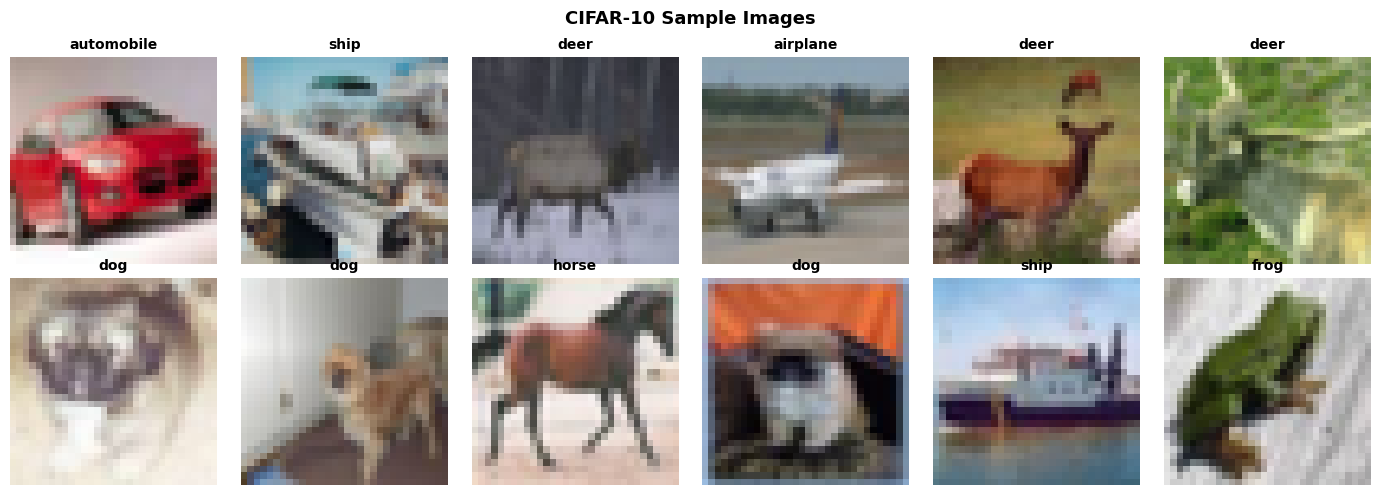

In [20]:
classes = trainset.classes

def show_images(loader, n=12):
  images, labels = next(iter(loader))

  images = images*0.5 + 0.5
  fig, axes = plt.subplots(2, 6, figsize=(14, 5))
  fig.suptitle('CIFAR-10 Sample Images',
                 fontsize=13, fontweight='bold')

  for i, ax in enumerate(axes.flat):
        if i < n:
            img = images[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(classes[labels[i]],
                        fontsize=10, fontweight='bold')
            ax.axis('off')

  plt.tight_layout()
  plt.show()

show_images(trainloader)

In [24]:
class CIFAR_CNN(nn.Module):
  def __init__(self):
    super(CIFAR_CNN, self).__init__()

    self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
    self.conv2 = nn.Conv2d(32, 32, 3, padding=1) # Corrected in_channels
    self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
    self.conv4 = nn.Conv2d(64, 64, 3, padding=1) # Corrected in_channels
    self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
    self.conv6 = nn.Conv2d(128, 128, 3, padding=1) # Corrected in_channels

    self.pool = nn.MaxPool2d(2, 2)

    self.bn1 = nn.BatchNorm2d(32)
    self.bn2 = nn.BatchNorm2d(64)
    self.bn3 = nn.BatchNorm2d(128)

    self.fc1 = nn.Linear(128 * 4 * 4, 256)
    self.fc2 = nn.Linear(256, 10)

    self.relu    = nn.ReLU()
    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
      # Block 1: (3,32,32) → (32,16,16)
      x = self.relu(self.conv1(x))
      x = self.relu(self.conv2(x))
      x = self.bn1(x)
      x = self.pool(x)           # 32x32 → 16x16

      # Block 2: (32,16,16) → (64,8,8)
      x = self.relu(self.conv3(x))
      x = self.relu(self.conv4(x))
      x = self.bn2(x)
      x = self.pool(x)           # 16x16 → 8x8

      # Block 3: (64,8,8) → (128,4,4)
      x = self.relu(self.conv5(x))
      x = self.relu(self.conv6(x))
      x = self.bn3(x)
      x = self.pool(x)           # 8x8 → 4x4

      # Flatten: (128,4,4) → 2048
      x = x.view(x.size(0), -1)

      # Classify
      x = self.relu(self.fc1(x))
      x = self.dropout(x)
      x = self.fc2(x)            # raw scores (logits)

      return x


model = CIFAR_CNN()

# Count parameters
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")
print(model)


Total parameters: 814,570
CIFAR_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
  (dr

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.5)

EPOCHS = 15
train_losses   = []
test_losses    = []
train_accs     = []
test_accs      = []

print(f"Training for {EPOCHS} epochs...")

Training for 15 epochs...


In [26]:
for epoch in range(EPOCHS):

    # ── Training phase ──
    model.train()
    running_loss    = 0.0
    correct_train   = 0
    total_train     = 0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss  += loss.item()
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc  = correct_train / total_train * 100

    model.eval()
    running_test  = 0.0
    correct_test  = 0
    total_test    = 0

    with torch.no_grad():
        for images, labels in testloader:
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            running_test += loss.item()
            _, predicted  = torch.max(outputs, 1)
            total_test   += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = running_test / len(testloader)
    test_acc  = correct_test / total_test * 100

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Step the scheduler
    scheduler.step()

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.3f} | "
          f"Train Acc: {train_acc:.1f}% | "
          f"Test Acc: {test_acc:.1f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.6f}")

Epoch  1/15 | Train Loss: 1.370 | Train Acc: 51.0% | Test Acc: 61.7% | LR: 0.001000
Epoch  2/15 | Train Loss: 0.932 | Train Acc: 67.6% | Test Acc: 72.0% | LR: 0.001000
Epoch  3/15 | Train Loss: 0.765 | Train Acc: 73.7% | Test Acc: 76.1% | LR: 0.001000
Epoch  4/15 | Train Loss: 0.651 | Train Acc: 77.6% | Test Acc: 78.3% | LR: 0.001000
Epoch  5/15 | Train Loss: 0.574 | Train Acc: 80.4% | Test Acc: 80.6% | LR: 0.000500
Epoch  6/15 | Train Loss: 0.407 | Train Acc: 86.0% | Test Acc: 82.4% | LR: 0.000500
Epoch  7/15 | Train Loss: 0.332 | Train Acc: 88.4% | Test Acc: 82.7% | LR: 0.000500
Epoch  8/15 | Train Loss: 0.277 | Train Acc: 90.3% | Test Acc: 83.1% | LR: 0.000500
Epoch  9/15 | Train Loss: 0.240 | Train Acc: 91.6% | Test Acc: 83.0% | LR: 0.000500
Epoch 10/15 | Train Loss: 0.205 | Train Acc: 92.8% | Test Acc: 82.8% | LR: 0.000250
Epoch 11/15 | Train Loss: 0.129 | Train Acc: 95.5% | Test Acc: 84.1% | LR: 0.000250
Epoch 12/15 | Train Loss: 0.094 | Train Acc: 96.7% | Test Acc: 84.0% | LR: 0

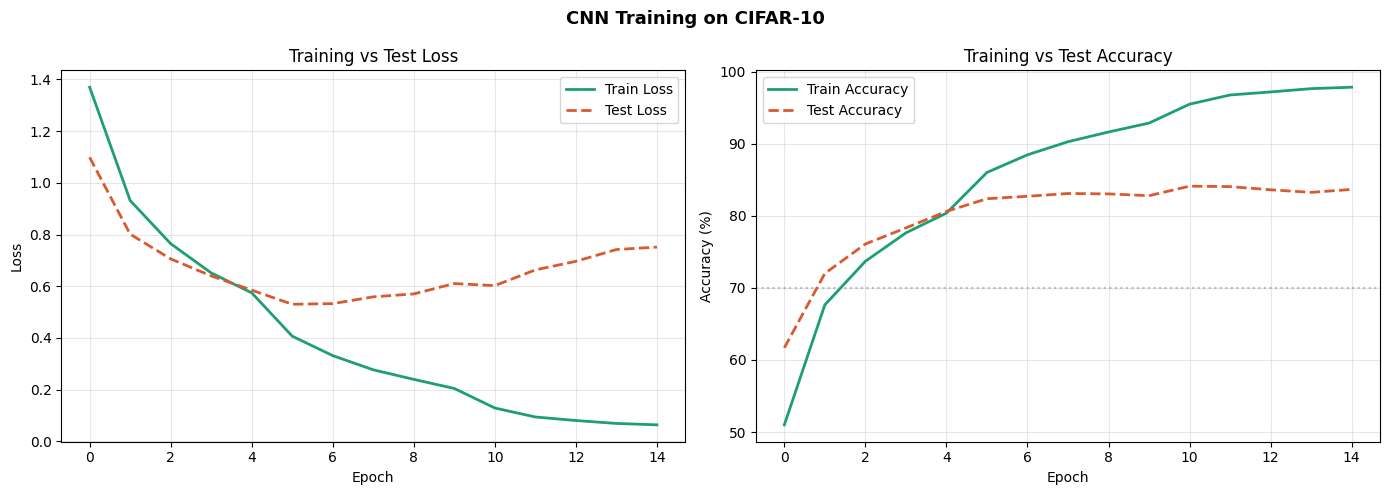

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color='#1D9E75',
         linewidth=2, label='Train Loss')
ax1.plot(test_losses,  color='#D85A30',
         linewidth=2, label='Test Loss', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, color='#1D9E75',
         linewidth=2, label='Train Accuracy')
ax2.plot(test_accs,  color='#D85A30',
         linewidth=2, label='Test Accuracy', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training vs Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(70, color='gray', linestyle=':',
            alpha=0.5, label='70% target')

plt.suptitle('CNN Training on CIFAR-10',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [28]:
class_correct = [0] * 10
class_total   = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs    = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_total[label]   += 1
            if predicted[i] == labels[i]:
                class_correct[label] += 1

print(f"{'Class':15} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 45)
for i in range(10):
    acc = class_correct[i] / class_total[i] * 100
    bar = '█' * int(acc / 5)
    print(f"{classes[i]:15} {class_correct[i]:>8} "
          f"{class_total[i]:>8} {acc:>8.1f}% {bar}")


Class            Correct    Total   Accuracy
---------------------------------------------
airplane             846     1000     84.6% ████████████████
automobile           917     1000     91.7% ██████████████████
bird                 744     1000     74.4% ██████████████
cat                  684     1000     68.4% █████████████
deer                 811     1000     81.1% ████████████████
dog                  801     1000     80.1% ████████████████
frog                 854     1000     85.4% █████████████████
horse                882     1000     88.2% █████████████████
ship                 911     1000     91.1% ██████████████████
truck                915     1000     91.5% ██████████████████


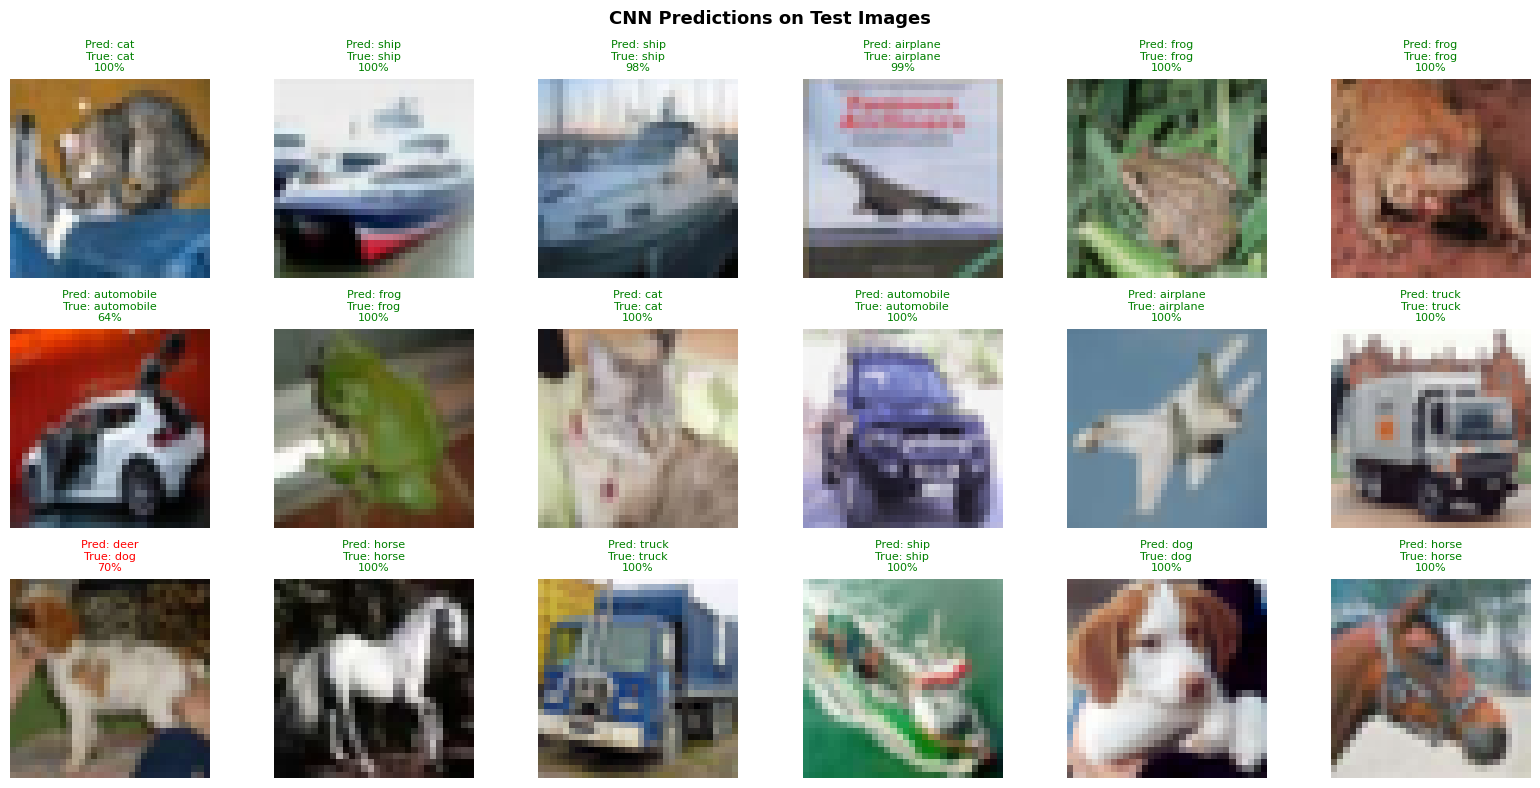

In [29]:
model.eval()
images, labels = next(iter(testloader))

with torch.no_grad():
    outputs = model(images)
    probs   = torch.softmax(outputs, dim=1)
    _, predicted = torch.max(outputs, 1)

# Unnormalize images for display
display_images = images * 0.5 + 0.5

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('CNN Predictions on Test Images',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < 18:
        img = display_images[i].permute(1, 2, 0).numpy()
        ax.imshow(img)

        pred_class   = classes[predicted[i]]
        actual_class = classes[labels[i]]
        confidence   = probs[i][predicted[i]].item() * 100

        color = 'green' if predicted[i] == labels[i] else 'red'
        ax.set_title(
            f"Pred: {pred_class}\n"
            f"True: {actual_class}\n"
            f"{confidence:.0f}%",
            fontsize=8, color=color
        )
        ax.axis('off')

plt.tight_layout()
plt.show()



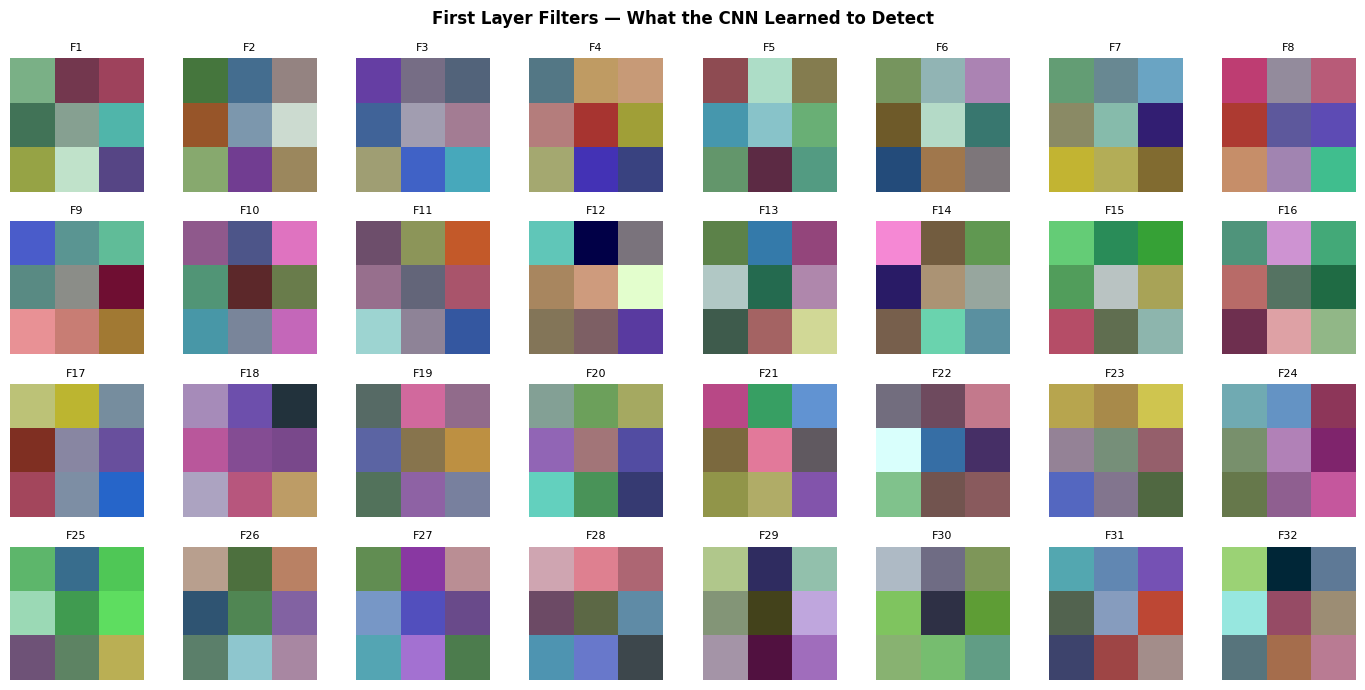


Each small image above is one learned filter.
Different colors = detecting different patterns:
  Edge-like filters → detecting boundaries
  Color filters     → detecting specific colors
  Texture filters   → detecting textures

Nobody told the CNN what to look for.
It discovered these patterns on its own
purely from seeing 50,000 images.



In [30]:
# Get the first conv layer filters
filters = model.conv1.weight.data.clone()

# Normalize for visualization
f_min  = filters.min()
f_max  = filters.max()
filters = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('First Layer Filters — What the CNN Learned to Detect',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < 32:
        filt = filters[i].permute(1, 2, 0).numpy()
        ax.imshow(filt)
        ax.set_title(f'F{i+1}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("""
Each small image above is one learned filter.
Different colors = detecting different patterns:
  Edge-like filters → detecting boundaries
  Color filters     → detecting specific colors
  Texture filters   → detecting textures

Nobody told the CNN what to look for.
It discovered these patterns on its own
purely from seeing 50,000 images.
""")

In [31]:
print("\n--- CNN vs Regular Neural Network ---")

class RegularNN(nn.Module):
    """Regular neural network — no convolutions"""
    def __init__(self):
        super().__init__()
        # Flatten 3×32×32 = 3072 inputs directly
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


nn_model  = RegularNN()
cnn_total = sum(p.numel() for p in model.parameters())
nn_total  = sum(p.numel() for p in nn_model.parameters())

print(f"CNN parameters:        {cnn_total:>10,}")
print(f"Regular NN parameters: {nn_total:>10,}")
print(f"""
CNN has fewer parameters but gets higher accuracy.
Why?

Regular NN:
  Treats each pixel independently
  No spatial understanding
  Pixel(0,0) has no relation to pixel(0,1)
  Expected accuracy: 50-55%

CNN:
  Understands spatial relationships
  Same filter detects pattern anywhere in image
  Parameter sharing = efficient learning
  Expected accuracy: 70-80%

This spatial understanding is why CNNs
dominate all image tasks.
""")


--- CNN vs Regular Neural Network ---
CNN parameters:           814,570
Regular NN parameters:  1,707,274

CNN has fewer parameters but gets higher accuracy.
Why?

Regular NN:
  Treats each pixel independently
  No spatial understanding
  Pixel(0,0) has no relation to pixel(0,1)
  Expected accuracy: 50-55%

CNN:
  Understands spatial relationships
  Same filter detects pattern anywhere in image
  Parameter sharing = efficient learning
  Expected accuracy: 70-80%

This spatial understanding is why CNNs
dominate all image tasks.



In [32]:
torch.save(model.state_dict(), 'cifar_cnn.pth')
print("Model saved to cifar_cnn.pth")

# Quick prediction function
def predict_image(img_tensor):
    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0))
        probs  = torch.softmax(output, dim=1)
        _, pred = torch.max(output, 1)
    return classes[pred.item()], probs[0][pred].item() * 100

# Test on one image
test_img, test_label = testset[0]
pred_class, confidence = predict_image(test_img)
print(f"\nSample prediction:")
print(f"Predicted: {pred_class} ({confidence:.1f}% confident)")
print(f"Actual:    {classes[test_label]}")

Model saved to cifar_cnn.pth

Sample prediction:
Predicted: cat (100.0% confident)
Actual:    cat
